<a href="https://colab.research.google.com/github/Frankieche24/White-Wine-Quality/blob/main/Machine_Learning_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Prediction: Linear Regression and Neural Network

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score



In [3]:
# Load the dataset directly from the UCI repository
# For white wine quality, the URL is slightly different
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
data = pd.read_csv(url, sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### 1. Data Preprocessing

Let's prepare the data by separating features (X) and the target variable (y), splitting it into training and testing sets, and scaling the features. This is a crucial step for both Linear Regression and Neural Network models.

In [4]:
X = data.drop("quality", axis=1).values    # shape (4898, 11)  ← INPUTs
y = data["quality"].values.reshape(-1, 1)  # shape (4898,  1)  ← OUTPUT

print(f"\nInputs  shape : {X.shape}   (samples × features)")
print(f"Output  shape : {y.shape}   (samples × 1)")


Inputs  shape : (4898, 11)   (samples × features)
Output  shape : (4898, 1)   (samples × 1)


In [5]:
# =============================================================================
# 3. TRAIN / INDEPENDENT TEST SPLIT
# =============================================================================
# 80 % becomes the TRAIN DATASET (used to fit the model).
# 20 % becomes the INDEPENDENT TEST DATASET (never seen during training —
# used only at the end to give an unbiased measure of real-world performance).

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTRAIN DATASET      : {X_train.shape[0]} samples")
print(f"INDEPENDENT TEST   : {X_test.shape[0]}  samples")



TRAIN DATASET      : 3918 samples
INDEPENDENT TEST   : 980  samples


In [9]:
import torch
# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Feature scaling ──────────────────────────────────────────────────────────
# Fit the scaler ONLY on train data to prevent data leakage into the test set.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── Convert to PyTorch tensors ───────────────────────────────────────────────
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

In [12]:
# =============================================================================
# 4. DATALOADER — BATCH iteration over the TRAIN DATASET
# =============================================================================
# A BATCH is a small subset of the TRAIN DATASET processed in one forward pass.
# Using mini-batches (instead of the full dataset at once) is more memory
# efficient and is the standard way to train neural networks.


BATCH_SIZE = 64   # ← BATCH size

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True
)


In [13]:
# =============================================================================
# 5. MODEL DEFINITION — Linear Regression
# =============================================================================
# The MODEL learns a linear mapping from INPUT features to the OUTPUT quality.
# A single nn.Linear layer implements exactly:
#
#   OUTPUT = W · INPUT + b
#
# where W (weights) and b (bias) are the parameters the model learns.

class LinearRegressionModel(nn.Module):
    """
    MODEL: single linear layer for regression.
    INPUT  : 11 physicochemical features
    OUTPUT : 1 continuous quality score
    """
    def __init__(self, input_dim: int, output_dim: int = 1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)  # OUTPUT = W·INPUT + b

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

INPUT_DIM  = X_train_t.shape[1]  # 11 features  ← INPUT dimension
OUTPUT_DIM = 1                    # quality score ← OUTPUT dimension

model = LinearRegressionModel(INPUT_DIM, OUTPUT_DIM)
print("\nMODEL architecture:")
print(model)


MODEL architecture:
LinearRegressionModel(
  (linear): Linear(in_features=11, out_features=1, bias=True)
)


In [14]:
# =============================================================================
# 6. LOSS FUNCTION & OPTIMISER
# =============================================================================
# The LOSS FUNCTION measures how far the MODEL's predictions are from the
# true OUTPUT values. Mean Squared Error (MSE) is the standard choice for
# linear regression:
#
#   MSE = (1/n) Σ (y_true − y_pred)²
#
# The optimiser (SGD) adjusts the MODEL's parameters after every BATCH
# to minimise the LOSS FUNCTION.

loss_fn   = nn.MSELoss()                          # ← LOSS FUNCTION
optimiser = optim.SGD(model.parameters(), lr=0.01)


In [15]:
# =============================================================================
# 7. TRAINING LOOP
# =============================================================================
# An EPOCH is one complete pass through the entire TRAIN DATASET.
# Within each EPOCH we iterate over every BATCH in the DataLoader.

NUM_EPOCHS = 200   # ← total number of EPOCHs

train_losses = []  # record average LOSS per EPOCH

print(f"\nStarting training for {NUM_EPOCHS} EPOCHs …\n")

for epoch in range(1, NUM_EPOCHS + 1):          # ← EPOCH loop

    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:       # ← BATCH loop over TRAIN DATASET
        optimiser.zero_grad()                   # reset gradients from last BATCH
        y_pred = model(X_batch)                 # PREDICT for current BATCH (forward pass)
        loss   = loss_fn(y_pred, y_batch)       # LOSS FUNCTION: compare PREDICT vs truth
        loss.backward()                         # back-propagation
        optimiser.step()                        # update MODEL parameters
        batch_losses.append(loss.item())

    avg_loss = np.mean(batch_losses)
    train_losses.append(avg_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"  EPOCH {epoch:>3}/{NUM_EPOCHS}  |  Train LOSS: {avg_loss:.4f}")

print("\nTraining complete.")


Starting training for 200 EPOCHs …

  EPOCH   1/200  |  Train LOSS: 13.4453
  EPOCH  20/200  |  Train LOSS: 0.5679
  EPOCH  40/200  |  Train LOSS: 0.5619
  EPOCH  60/200  |  Train LOSS: 0.5644
  EPOCH  80/200  |  Train LOSS: 0.5661
  EPOCH 100/200  |  Train LOSS: 0.5675
  EPOCH 120/200  |  Train LOSS: 0.5641
  EPOCH 140/200  |  Train LOSS: 0.5621
  EPOCH 160/200  |  Train LOSS: 0.5620
  EPOCH 180/200  |  Train LOSS: 0.5608
  EPOCH 200/200  |  Train LOSS: 0.5656

Training complete.


In [16]:
# =============================================================================
# 8. EVALUATION ON INDEPENDENT TEST DATASET
# =============================================================================
# We now PREDICT on the INDEPENDENT TEST DATASET — data the MODEL has never
# seen during training. This gives an unbiased estimate of real-world performance.

model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t)   # ← PREDICT on INDEPENDENT TEST DATASET

y_test_np = y_test_t.numpy()
y_pred_np = y_pred_t.numpy()

mse  = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_np, y_pred_np)

print(f"\n── Test-set metrics (INDEPENDENT TEST DATASET) ──")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")



── Test-set metrics (INDEPENDENT TEST DATASET) ──
  MSE  : 0.5661
  RMSE : 0.7524
  R²   : 0.2691


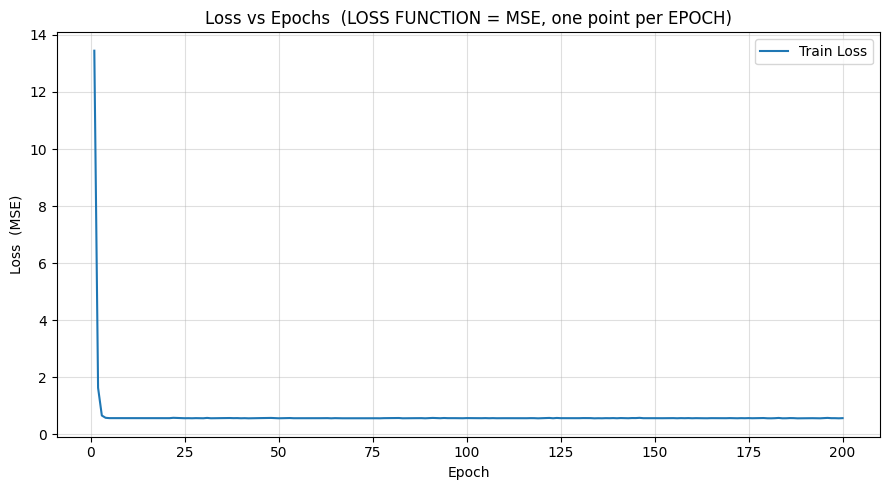

Saved: loss_vs_epochs.png


In [17]:
# =============================================================================
# 9. PLOT 1 — Loss vs Epochs
# =============================================================================
# Required output: LOSS FUNCTION value (y-axis) vs EPOCH number (x-axis).

fig1, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss  (MSE)")
ax1.set_title("Loss vs Epochs  (LOSS FUNCTION = MSE, one point per EPOCH)")
ax1.legend()
ax1.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("loss_vs_epochs.png", dpi=150)
plt.show()
print("Saved: loss_vs_epochs.png")

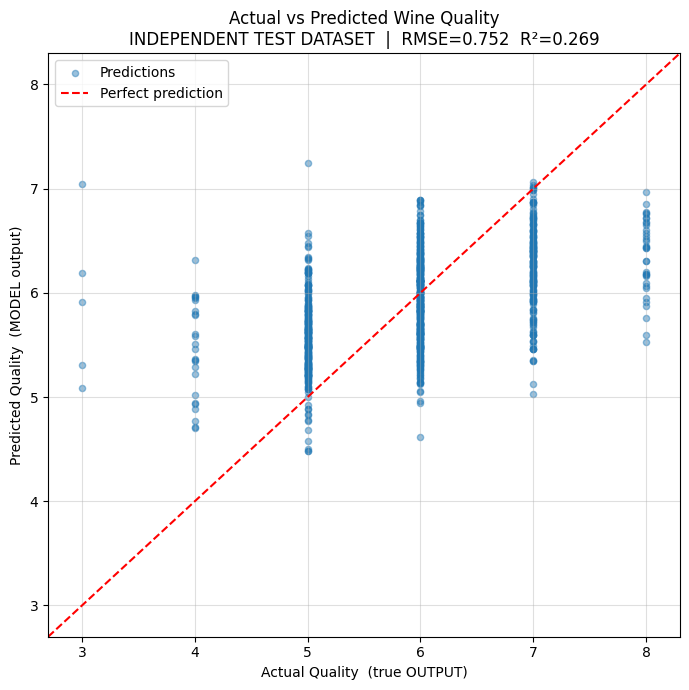

Saved: actual_vs_predicted.png


In [18]:
# =============================================================================
# 10. PLOT 2 — Actual vs Predicted values (INDEPENDENT TEST DATASET)
# =============================================================================
# Required output: actual vs PREDICTED OUTPUT on the INDEPENDENT TEST DATASET.
# Points on the dashed diagonal = perfect predictions.

fig2, ax2 = plt.subplots(figsize=(7, 7))
ax2.scatter(y_test_np, y_pred_np, alpha=0.45, s=20, label="Predictions")
lims = [min(y_test_np.min(), y_pred_np.min()) - 0.3,
        max(y_test_np.max(), y_pred_np.max()) + 0.3]
ax2.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax2.set_xlim(lims); ax2.set_ylim(lims)
ax2.set_xlabel("Actual Quality  (true OUTPUT)")
ax2.set_ylabel("Predicted Quality  (MODEL output)")
ax2.set_title(f"Actual vs Predicted Wine Quality\n"
              f"INDEPENDENT TEST DATASET  |  RMSE={rmse:.3f}  R²={r2:.3f}")
ax2.legend()
ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved: actual_vs_predicted.png")
